Name : Nisha Pragane | Rollno:13 | PRN :1252090013| DIV :SEDA| Batch:B1

Assignment 2: Perform the following operations using  Python on the data sets:
1. Compute and display summary statistics for each feature available in the dataset. (e.g. minimum value, maximum value, mean, range, standard deviation, variance and percentiles
2. Illustrate the feature distributions using histogram.
3. Data cleaning, Data integration, Data transformation, Data model building (e.g. Classification)

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [ ]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check Shape of Dataset

In [ ]:
train.shape


(891, 12)

Summary Statistics

In [ ]:
train.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Range of each feature

In [ ]:
train.max(numeric_only=True) - train.min(numeric_only=True)

,0
PassengerId,890.0000
Survived,1.0000
Pclass,2.0000
Age,79.5800
SibSp,8.0000
Parch,6.0000
Fare,512.3292


Variance

In [ ]:
train.var(numeric_only=True)

,0
PassengerId,66231.000000
Survived,0.236772
Pclass,0.699015
Age,211.019125
SibSp,1.216043
Parch,0.649728
Fare,2469.436846


Standard Deviation

In [ ]:
train.std(numeric_only=True)

,0
PassengerId,257.353842
Survived,0.486592
Pclass,0.836071
Age,14.526497
SibSp,1.102743
Parch,0.806057
Fare,49.693429


Percentiles

In [ ]:
train.select_dtypes(include=np.number).quantile([0.25, 0.5, 0.75])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0.25,223.5,0.0,2.0,20.125,0.0,0.0,7.9104
0.50,446.0,0.0,3.0,28.000,0.0,0.0,14.4542
0.75,668.5,1.0,3.0,38.000,1.0,0.0,31.0000


Data Types

In [ ]:
train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


Histograms for Feature Distribution

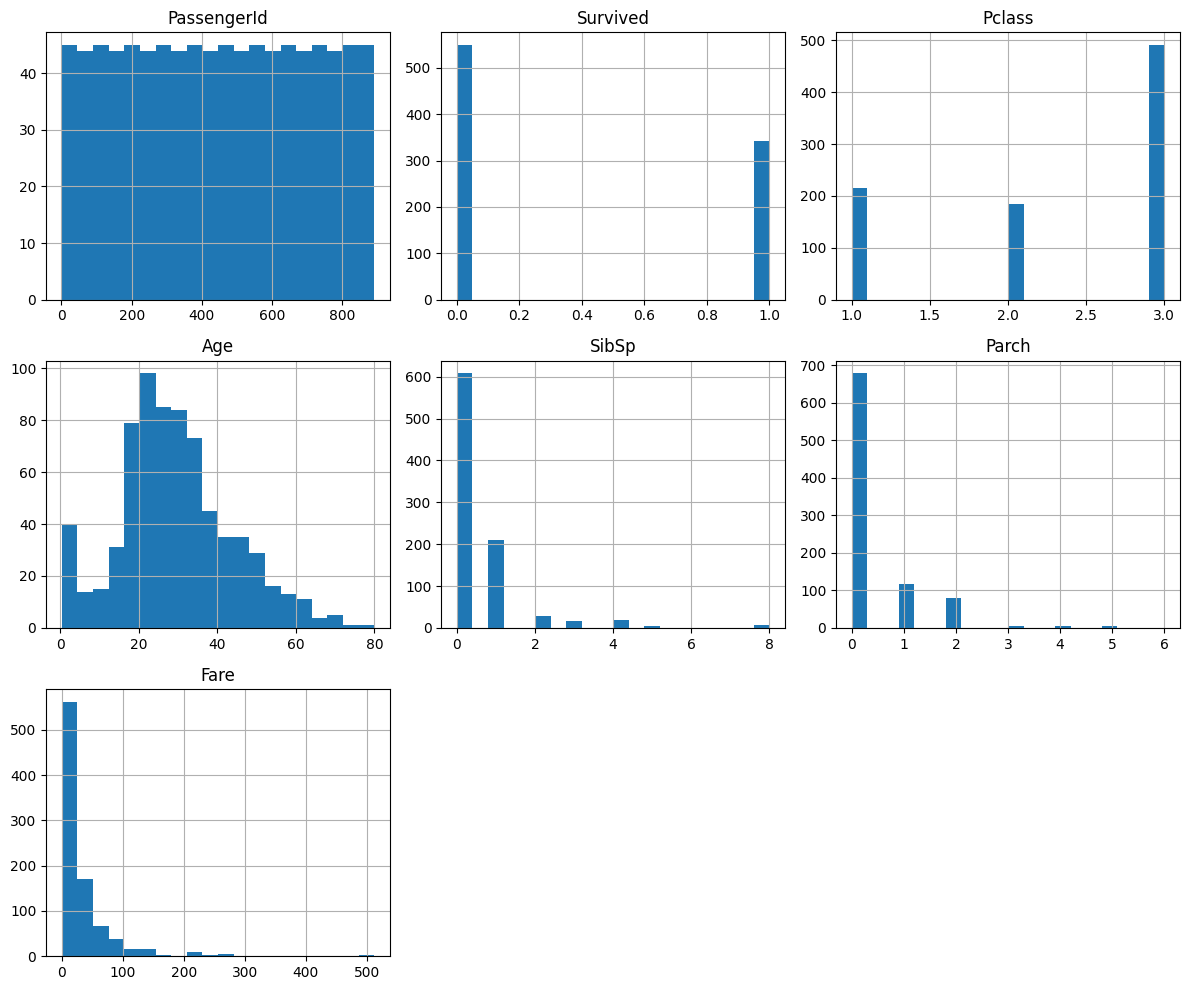

In [ ]:
train.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

Data Cleaning

In [ ]:
train.fillna(value=5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,5,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,5,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,5,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,5,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,5.0,1,2,W./C. 6607,23.4500,5,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Find Missing values

In [ ]:
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train['Cabin'] = train['Cabin'].fillna('Unknown')
test['Age'] = test['Age'].fillna(test['Age'].median())
test['Fare'] = test['Fare'].fillna(test['Fare'].median())
test['Cabin'] = test['Cabin'].fillna('Unknown')

Remove Duplicates

In [ ]:
train = train.drop_duplicates()

In [ ]:
train.dropna(how="any")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unknown,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,Unknown,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
pd.isna(train)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False


Data Integration (train + test)

In [ ]:
combined = pd.concat([train, test], axis=0, ignore_index=True)
combined.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


Data Transformation

1.   Drop Irrelevant Columns
2.   Encode Categorical Variables

In [ ]:
columns_to_drop = ['PassengerId','Name','Ticket','Cabin']
train = train.drop(columns=[col for col in columns_to_drop if col in train.columns], axis=1)
test = test.drop(columns=[col for col in columns_to_drop if col in test.columns], axis=1)
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

Concat


In [ ]:
import pandas as pd

academic1 = pd.DataFrame({
    "Student_ID": [101, 102, 103],
    "Name": ["Nisha", "Sohaa", "Apurv"],
    "Marks": [85, 92, 78]
})

academic2 = pd.DataFrame({
    "Student_ID": [104, 105],
    "Name": ["Priya", "Karan"],
    "Marks": [88, 95]
})

attendance = pd.DataFrame({
    "Student_ID": [101, 102, 103],
    "Attendance (%)": [90, 95, 85]
})

Vertical Merge

In [ ]:
vertical_merge = pd.concat([academic1, academic2], axis=0)
print(vertical_merge)
print("\n")

   Student_ID   Name  Marks
0         101  Nisha     85
1         102  Sohaa     92
2         103  Apurv     78
0         104  Priya     88
1         105  Karan     95




Horizontal Merge

In [ ]:
horizontal_merge = pd.concat([academic1, attendance], axis=1)
print(horizontal_merge)

   Student_ID   Name  Marks  Student_ID  Attendance (%)
0         101  Nisha     85         101              90
1         102  Sohaa     92         102              95
2         103  Apurv     78         103              85


Merge

In [ ]:
academic = pd.DataFrame({
    "Student_ID": [101, 102, 103],
    "Name": ["Nisha", "Sohaa", "Apurv"],
    "Marks": [85, 92, 78]
})
attendance = pd.DataFrame({
    "Student_ID": [101, 102],
    "Attendance (%)": [90, 95]
})
inner_join = academic.merge(attendance, on="Student_ID", how="inner")
print(inner_join, "\n")

   Student_ID   Name  Marks  Attendance (%)
0         101  Nisha     85              90
1         102  Sohaa     92              95 



Types Of Join

In [ ]:
pd.merge(academic, attendance, on='Student_ID', how='inner')   # Common records
pd.merge(academic, attendance, on='Student_ID', how='left')    # All left + matches
pd.merge(academic, attendance, on='Student_ID', how='right')   # All right + matches
pd.merge(academic, attendance, on='Student_ID', how='outer')   # All records

,Student_ID,Name,Marks,Attendance (%)
0,101,Nisha,85,90
1,102,Sohaa,92,95
2,103,Apurv,78,85


Integration Using Index Using join() Joins datasets using index instead of columns.

In [ ]:
df1 = academic.set_index('Student_ID')
df2 = attendance.set_index('Student_ID')

integrated_data = df1.join(df2)

print(integrated_data)

             Name  Marks  Attendance (%)
Student_ID                              
101         Nisha     85            90.0
102         Sohaa     92            95.0
103         Apurv     78             NaN


Integrating Data from Multiple File Formats

In [ ]:
csv_data = pd.read_csv('Student Degree College Data.csv')
excel_data = pd.read_excel('Student Degree College Data.xlsx')

final_data = pd.merge(csv_data, excel_data, on='form_no')